# Lesson 3: Advanced Usage (LZGraph)

In Lessons 1 and 2 we built graphs and computed distributional
summaries from them. This lesson covers the four toolkits that
typically come *next* in a real analysis:

1. **Gene distributions.** Once you have V/J calls in your graph,
   you can read marginal and joint gene distributions directly.
2. **Set algebra.** Union, intersection, difference, and weighted
   merge let you combine two repertoires into a third graph that you
   can analyse with everything you learned in Lesson 2.
3. **Bayesian posterior updates.** Take a population-level prior and
   adapt it to a specific patient or condition with a controlled
   prior-strength parameter.
4. **ML feature extraction.** Three flavors of fixed-size feature
   vector you can drop straight into a scikit-learn pipeline.

By the end you'll be able to:

- Inspect $P(V)$, $P(J)$, and $P(V,J)$ from a graph
- Run gene-conditioned simulation in three modes (fixed V, fixed J,
  sample from the joint)
- Combine graphs using the `|`, `&`, `-` operators and
  `weighted_merge`
- Personalize a population graph for a target sample using
  `posterior(...)` and tune the prior strength with the `kappa`
  parameter
- Extract structural summary vectors (`feature_stats`),
  reference-aligned vectors (`feature_aligned`), and positional mass
  profiles (`feature_mass_profile`)
- Plug those vectors into a scikit-learn classifier as a starting
  point for downstream ML


In [1]:
from LZGraphs import LZGraph, set_log_level
import numpy as np
import csv
import math
import matplotlib.pyplot as plt


## Setup: load data and build the reference graph

Same 5,000-sequence repertoire from Lessons 1 and 2, with V/J gene
calls attached so that the gene-distribution sections work.


In [2]:
sequences, v_genes, j_genes = [], [], []
with open('../data/ExampleData3.csv') as f:
    for row in csv.DictReader(f):
        sequences.append(row['cdr3_amino_acid'])
        v_genes.append(row['V'])
        j_genes.append(row['J'])

graph = LZGraph(sequences, variant='aap', v_genes=v_genes, j_genes=j_genes)
print(graph)
print(f'has_gene_data: {graph.has_gene_data}')


LZGraph(variant='aap', nodes=1721, edges=9644)
has_gene_data: True


## 1. Gene distributions

When a graph is built with `v_genes` and `j_genes`, the package stores
both the marginal gene distributions ($P(V)$, $P(J)$) and the joint
distribution ($P(V, J)$). All three are directly accessible as
properties; they are read-only views on the graph's learned
parameters.


In [3]:
# V-gene marginals: dict-like (V name -> probability)
print('Top 10 V genes by frequency:')
top_v = sorted(graph.v_marginals.items(), key=lambda kv: -kv[1])[:10]
for name, prob in top_v:
    print(f'  {name:<20}  {prob:.4f}')


Top 10 V genes by frequency:
  TRBV19-1*01           0.0774
  TRBV7-2*01            0.0730
  TRBV5-1*01            0.0688
  TRBV7-9*01            0.0624
  TRBV18-1*01           0.0504
  TRBV2-1*01            0.0492
  TRBV6-5*01            0.0456
  TRBV4-3*01            0.0430
  TRBV9-1*01            0.0420
  TRBV27-1*01           0.0366


In [4]:
# J-gene marginals
print('J genes (all):')
for name, prob in sorted(graph.j_marginals.items(), key=lambda kv: -kv[1]):
    print(f'  {name:<20}  {prob:.4f}')


J genes (all):
  TRBJ1-2*01            0.1568
  TRBJ2-7*01            0.1448
  TRBJ1-1*01            0.1404
  TRBJ2-3*01            0.0962
  TRBJ2-1*01            0.0916
  TRBJ1-5*01            0.0772
  TRBJ2-5*01            0.0678
  TRBJ2-2*01            0.0574
  TRBJ1-6*01            0.0512
  TRBJ1-4*01            0.0480
  TRBJ1-3*01            0.0434
  TRBJ2-6*01            0.0168
  TRBJ2-4*01            0.0084


In [5]:
# Joint VJ distribution: list of dicts (one per observed V,J pair)
print(f'Number of distinct VJ pairs: {len(graph.vj_distribution)}')
print()
print('Top 5 VJ pairs:')
top_vj = sorted(graph.vj_distribution, key=lambda d: -d['prob'])[:5]
for d in top_vj:
    print(f'  V={d["v"]:<15}  J={d["j"]:<15}  P(V,J)={d["prob"]:.4f}')


Number of distinct VJ pairs: 494

Top 5 VJ pairs:
  V=TRBV19-1*01      J=TRBJ1-2*01       P(V,J)=0.0136
  V=TRBV19-1*01      J=TRBJ1-5*01       P(V,J)=0.0124
  V=TRBV7-2*01       J=TRBJ2-7*01       P(V,J)=0.0112
  V=TRBV7-2*01       J=TRBJ1-2*01       P(V,J)=0.0108
  V=TRBV19-1*01      J=TRBJ1-1*01       P(V,J)=0.0102


The marginals are useful for repertoire-level QC ("does my V usage
match what I expect from the donor?") and the joint distribution is
the input to gene-conditioned simulation (next section).


## 2. Gene-conditioned simulation in depth

In Lesson 1 you saw the basic `simulate(n, seed)` call. With V/J gene
data attached, you have three additional modes:

| Mode | What it does |
|---|---|
| `v_gene='TRBV5-1*01'` | Only sample walks whose joint V/J came from this V |
| `j_gene='TRBJ2-7*01'` | Same, conditioned on a specific J |
| `sample_genes=True` | Draw $(V, J)$ from $P(V,J)$ for each walk, then sample |

The unconditioned `simulate(n)` form just sums over the gene
distribution implicitly. Use the conditioned forms when you want to
study or generate repertoires that respect a specific V or J usage.


In [6]:
# Mode 1: fixed V gene
top_v_name = sorted(graph.v_marginals.items(), key=lambda kv: -kv[1])[0][0]
res_v = graph.simulate(5, seed=42, v_gene=top_v_name)
print(f'Conditioned on V = {top_v_name}:')
for s, v, j in zip(res_v.sequences, res_v.v_genes, res_v.j_genes):
    print(f'  {s:<25}  V={v}  J={j}')


Conditioned on V = TRBV19-1*01:
  CATRENPGDLFF               V=TRBV19-1*01  J=
  CASSSGLREQHF               V=TRBV19-1*01  J=
  CASSRDIANTQPYFF            V=TRBV19-1*01  J=
  CASSERRGNQEKLHF            V=TRBV19-1*01  J=
  CASSYRTGLFF                V=TRBV19-1*01  J=


In [7]:
# Mode 2: fixed J gene
top_j_name = sorted(graph.j_marginals.items(), key=lambda kv: -kv[1])[0][0]
res_j = graph.simulate(5, seed=42, j_gene=top_j_name)
print(f'Conditioned on J = {top_j_name}:')
for s, v, j in zip(res_j.sequences, res_j.v_genes, res_j.j_genes):
    print(f'  {s:<25}  V={v}  J={j}')


Conditioned on J = TRBJ1-2*01:
  CAISPRGAGTF                V=  J=TRBJ1-2*01
  CASSLGQGDGYTF              V=  J=TRBJ1-2*01
  CASSPLDRNYGYTF             V=  J=TRBJ1-2*01
  CASSSTVGDNYGYTF            V=  J=TRBJ1-2*01
  CASSLGGAYNGYTF             V=  J=TRBJ1-2*01


In [8]:
# Mode 3: sample from joint VJ
res_joint = graph.simulate(5, seed=42, sample_genes=True)
print('Sampled (V, J) from joint distribution:')
for s, v, j in zip(res_joint.sequences, res_joint.v_genes, res_joint.j_genes):
    print(f'  {s:<25}  V={v}  J={j}')


Sampled (V, J) from joint distribution:
  CASRTGPQEYNEQF             V=TRBV5-1*01  J=TRBJ2-1*01
  CASSENGVSGTF               V=TRBV6-5*01  J=TRBJ1-2*01
  CASTSGTGQYYGYTF            V=TRBV7-8*01  J=TRBJ1-2*01
  CASSLGRNTEAFFF             V=TRBV5-6*01  J=TRBJ1-1*01
  CASSTSGGGGNSPLHF           V=TRBV5-1*01  J=TRBJ1-6*01


## 3. Set algebra: union, intersection, difference

Combining graphs is one of the most useful workflows: build a graph
per sample, then aggregate or compare them at the graph level rather
than at the sequence level.

| Operator | Method | Edge weights |
|---|---|---|
| `g1 \| g2` | `union(g2)` | sum of counts from both graphs |
| `g1 & g2` | `intersection(g2)` | min of counts (only edges in *both*) |
| `g1 - g2` | `difference(g2)` | g1 counts minus g2 counts (clipped to non-negative) |

All three return a new `LZGraph` of the same variant. The resulting
graph is a fully usable LZGraph: you can score, simulate, save, etc.

> **Edges vs nodes.** Intersection and difference operate on
> *edges*; the resulting graph keeps only the nodes that have at
> least one surviving edge (plus the sentinels). So node-level set
> identities don't hold exactly, but edge-level ones do:
> $|A \cup B|_{\text{edges}} = |A|_{\text{edges}} + |B|_{\text{edges}} - |A \cap B|_{\text{edges}}$.

In [9]:
# Split repertoire into two equal halves
g_a = LZGraph(sequences[:2500], variant='aap',
              v_genes=v_genes[:2500], j_genes=j_genes[:2500])
g_b = LZGraph(sequences[2500:], variant='aap',
              v_genes=v_genes[2500:], j_genes=j_genes[2500:])
print(f'g_a: {g_a}')
print(f'g_b: {g_b}')


g_a: LZGraph(variant='aap', nodes=1355, edges=6384)
g_b: LZGraph(variant='aap', nodes=1338, edges=6293)


In [10]:
g_union = g_a | g_b
g_inter = g_a & g_b
g_diff_a = g_a - g_b
g_diff_b = g_b - g_a

print(f'g_a | g_b: {g_union}')
print(f'g_a & g_b: {g_inter}')
print(f'g_a - g_b: {g_diff_a}')
print(f'g_b - g_a: {g_diff_b}')


g_a | g_b: LZGraph(variant='aap', nodes=1721, edges=9644)
g_a & g_b: LZGraph(variant='aap', nodes=823, edges=3033)
g_a - g_b: LZGraph(variant='aap', nodes=1300, edges=4407)
g_b - g_a: LZGraph(variant='aap', nodes=1291, edges=4277)


In [11]:
# Sanity check: at the edge level, |A ∪ B| = |A| + |B| - |A ∩ B|
expected_union_edges = g_a.n_edges + g_b.n_edges - g_inter.n_edges
print(f'g_a edges:        {g_a.n_edges:,d}')
print(f'g_b edges:        {g_b.n_edges:,d}')
print(f'intersection:     {g_inter.n_edges:,d}')
print(f'union (expected): {expected_union_edges:,d}')
print(f'union (actual):   {g_union.n_edges:,d}')
print(f'match:            {g_union.n_edges == expected_union_edges}')

# And the union of the two halves should equal the full repertoire graph
print()
print(f'union nodes: {g_union.n_nodes:,d}   full graph: {graph.n_nodes:,d}   '
      f'match: {g_union.n_nodes == graph.n_nodes}')
print(f'union edges: {g_union.n_edges:,d}   full graph: {graph.n_edges:,d}   '
      f'match: {g_union.n_edges == graph.n_edges}')

g_a edges:        6,384
g_b edges:        6,293
intersection:     3,033
union (expected): 9,644
union (actual):   9,644
match:            True

union nodes: 1,721   full graph: 1,721   match: True
union edges: 9,644   full graph: 9,644   match: True


## 4. Weighted merge: proportional blending

`weighted_merge(other, alpha, beta)` is the smooth-blend version of
union: edge weights become `alpha * w_self + beta * w_other`. Use it
when you want to combine two repertoires with different per-sample
weights (e.g. donor 1 contributed 70% of the data, donor 2 only 30%)
without re-collecting from raw sequences.


In [12]:
# 70-30 merge
g_merged = g_a.weighted_merge(g_b, alpha=0.7, beta=0.3)
print(f'0.7 * g_a + 0.3 * g_b: {g_merged}')

# Compare its pgen for an in-sample sequence to the un-blended graphs
seq = sequences[0]
print(f'log P({seq!r}):')
print(f'  in g_a:     {g_a.pgen(seq):.4f}')
print(f'  in g_b:     {g_b.pgen(seq):.4f}')
print(f'  in merged:  {g_merged.pgen(seq):.4f}')


0.7 * g_a + 0.3 * g_b: LZGraph(variant='aap', nodes=1402, edges=6826)
log P('CASSGLAGSRSYNEQFF'):
  in g_a:     -21.6392
  in g_b:     -690.7755
  in merged:  -21.3961


## 5. Bayesian posterior personalization

Take a population graph (the prior) and update it with a small batch
of patient-specific sequences (the new evidence). The result is a
posterior graph whose edge weights blend the two with controlled
strength:

$$ w_{\text{post}}(u \to v) = \frac{\kappa\, w_{\text{prior}}(u \to v) \;+\; c_{\text{ind}}(u \to v)}{\kappa + n_{\text{ind}}(u)} $$

where $c_{\text{ind}}(u \to v)$ is the number of times the new data
takes the $u \to v$ transition and $n_{\text{ind}}(u)$ is the total
out-flow at $u$ in the new data. $\kappa$ acts as a **Dirichlet
pseudocount** for the prior:

- High $\kappa$ (e.g. 100): the posterior stays close to the prior
- Low $\kappa$ (e.g. 0.1): the new data dominates

The posterior graph keeps the **same node and edge structure** as
the prior. Posterior re-weighting cannot add new nodes or edges, so
patient-specific sequences whose LZ walks would require novel
transitions still return the log-EPS floor.


In [13]:
# Prior built from the first 1,000 sequences (the "population")
prior = LZGraph(sequences[:1000], variant='aap')
new_data = sequences[1000:1500]   # 500 new "patient-specific" sequences
print(f'Prior:    {prior}')
print(f'New data: {len(new_data)} sequences')

# Personalize at several kappa values
test_seq = sequences[5]   # in-prior sequence; we want to see how its log-P shifts
print()
print(f'log P({test_seq!r}) shift as we vary kappa (prior strength):')
print(f'  prior:                {prior.pgen(test_seq):>8.4f}')
for kappa in [0.1, 1.0, 10.0, 100.0]:
    post = prior.posterior(new_data, kappa=kappa)
    print(f'  posterior, kappa={kappa:>5.1f}:  {post.pgen(test_seq):>8.4f}')


Prior:    LZGraph(variant='aap', nodes=997, edges=3585)
New data: 500 sequences

log P('CASSPQDRPNYGYTF') shift as we vary kappa (prior strength):
  prior:                -15.7572
  posterior, kappa=  0.1:  -21.0398
  posterior, kappa=  1.0:  -18.8588
  posterior, kappa= 10.0:  -17.1494
  posterior, kappa=100.0:  -16.1036


Read the table above: with `kappa=0.1` (very weak prior), the new
data dominates and the log-P of the test sequence moves significantly.
At `kappa=100`, the prior dominates and the posterior barely shifts.
This is the dial you use to control how much you trust the patient's
sample vs the population baseline.


## 6. ML feature: structural summary (`feature_stats`)

`feature_stats()` returns a 15-element vector of structural summary
statistics. These are global numbers describing the graph as a whole:

| Index | Quantity |
|---|---|
| 0  | number of nodes |
| 1  | number of edges |
| 2  | number of initial states |
| 3  | number of terminal states |
| 4-8  | Hill numbers $D(0)$, $D(0.5)$, $D(1)$, $D(2)$, $D(5)$ |
| 9  | Shannon entropy in nats |
| 10 | dynamic range in orders of magnitude |
| 11-12 | mean and std of per-node stop probability |
| 13 | max out-degree |
| 14 | uniformity (= $D(1) / D(0)$) |

Drop the vector straight into a sklearn pipeline; one row per graph.


In [14]:
stats = graph.feature_stats()
labels = ['nodes', 'edges', 'n_initial', 'n_terminal',
          'D(0)', 'D(0.5)', 'D(1)', 'D(2)', 'D(5)',
          'entropy_nats', 'dyn_range', 'mean_stop', 'std_stop',
          'max_out_deg', 'uniformity']
print(f'feature_stats: shape {stats.shape}')
for label, val in zip(labels, stats):
    print(f'  {label:<14}  {val:.4f}')


feature_stats: shape (15,)
  nodes           1721.0000
  edges           9644.0000
  n_initial       1.0000
  n_terminal      28.0000
  D(0)            1478336576163.2683
  D(0.5)          8533185253.4266
  D(1)            186650015.3912
  D(2)            5856871.4905
  D(5)            324294.2938
  entropy_nats    19.0614
  dyn_range       10.1649
  mean_stop       28.0000
  std_stop        0.0163
  max_out_deg     109.0000
  uniformity      0.0005


## 7. ML feature: reference-aligned vector (`feature_aligned`)

`feature_stats` gives you a *global* numerical summary. To compare
two *specific* graphs, you usually want the same shape of vector with
the *same coordinates* across all graphs in your dataset, so that a
classifier can compare element-wise.

`feature_aligned(query)` does exactly that: the **reference graph
defines the coordinate space** (one slot per reference node), and
the query graph is projected into it. Slots get the query graph's
probability on each shared reference node; nodes in the reference
but not the query get 0.

Two facts to remember:

- The output vector's length is `self.n_nodes` (the reference's node
  count). Two different reference graphs give two different feature
  spaces; pick one reference for your whole study.
- The query graph is used read-only; it can have nodes the reference
  doesn't, those just get dropped.


In [15]:
# Build a reference and a couple of query graphs
reference = graph
query_a   = g_a
query_b   = g_b

feat_a = reference.feature_aligned(query_a)
feat_b = reference.feature_aligned(query_b)

print(f'Reference n_nodes:       {reference.n_nodes}')
print(f'feat_a shape:            {feat_a.shape}  nonzero: {np.count_nonzero(feat_a)}')
print(f'feat_b shape:            {feat_b.shape}  nonzero: {np.count_nonzero(feat_b)}')
print()
print(f'Each row is a fixed-size feature vector you can stack into a matrix:')
X = np.stack([feat_a, feat_b])
print(f'  matrix shape: {X.shape}  (2 samples x 1721 features)')


Reference n_nodes:       1721
feat_a shape:            (1721,)  nonzero: 1328
feat_b shape:            (1721,)  nonzero: 1312

Each row is a fixed-size feature vector you can stack into a matrix:
  matrix shape: (2, 1721)  (2 samples x 1721 features)


## 8. ML feature: positional mass profile (`feature_mass_profile`)

`feature_mass_profile(max_pos)` returns a fixed-length vector where
index $k$ holds the cumulative probability mass at LZ76 walk
position $k$. This is a coarse positional fingerprint of the
distribution: short sequences contribute mass to low indices, long
sequences contribute to high indices.

Useful as a low-dimensional fingerprint that does *not* depend on
having a shared node space across graphs.


In [16]:
profile = graph.feature_mass_profile(max_pos=30)
print(f'mass profile shape: {profile.shape}')
print(f'mass sum:           {profile.sum():.4f}  (should be near 1.0)')
print(f'peak position:      {np.argmax(profile)}')


mass profile shape: (31,)
mass sum:           1.0000  (should be near 1.0)
peak position:      13


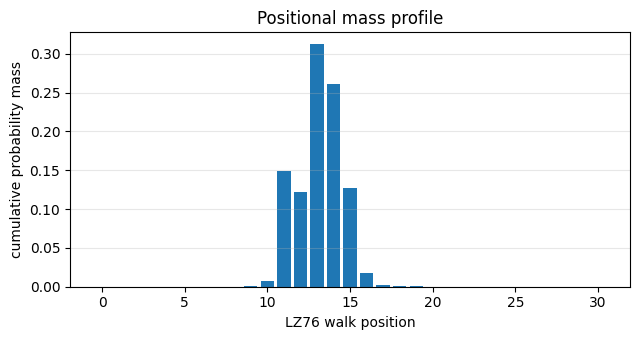

In [17]:
# Plot it
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(range(len(profile)), profile)
ax.set_xlabel('LZ76 walk position')
ax.set_ylabel('cumulative probability mass')
ax.set_title('Positional mass profile')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 9. End-to-end: a tiny V-gene classifier

To put it all together, here's a small pipeline that uses the
package's feature vectors to predict V-gene usage from sequence
shape.

The setup: pick the two most common V genes in the dataset, build a
graph for each (using only their respective sequences as training
data), then for each held-out sequence we build a *singleton* graph
and project it into both reference graphs with `feature_aligned`. The
concatenated pair of aligned vectors becomes the feature for a
logistic-regression classifier.


In [18]:
from collections import Counter

# Pick the two most common V genes
v_counts = Counter(v_genes)
top2_v = [v for v, _ in v_counts.most_common(2)]
print(f'Two most common V genes: {top2_v}')

# Filter sequences for each class
idx_0 = [i for i, v in enumerate(v_genes) if v == top2_v[0]]
idx_1 = [i for i, v in enumerate(v_genes) if v == top2_v[1]]
print(f'Class 0 ({top2_v[0]}): {len(idx_0)} sequences')
print(f'Class 1 ({top2_v[1]}): {len(idx_1)} sequences')


Two most common V genes: ['TRBV19-1*01', 'TRBV7-2*01']
Class 0 (TRBV19-1*01): 387 sequences
Class 1 (TRBV7-2*01): 365 sequences


In [19]:
# Use the first 70% of each class as training, last 30% as test
split0 = int(0.7 * len(idx_0))
split1 = int(0.7 * len(idx_1))

train_0 = [sequences[i] for i in idx_0[:split0]]
train_1 = [sequences[i] for i in idx_1[:split1]]
test_0  = [sequences[i] for i in idx_0[split0:]]
test_1  = [sequences[i] for i in idx_1[split1:]]
print(f'Train: class0 = {len(train_0)}, class1 = {len(train_1)}')
print(f'Test:  class0 = {len(test_0)}, class1 = {len(test_1)}')

# Build a reference graph per class
ref0 = LZGraph(train_0, variant='aap')
ref1 = LZGraph(train_1, variant='aap')
print(f'ref0: {ref0}')
print(f'ref1: {ref1}')


Train: class0 = 270, class1 = 255
Test:  class0 = 117, class1 = 110
ref0: LZGraph(variant='aap', nodes=559, edges=1414)
ref1: LZGraph(variant='aap', nodes=511, edges=1272)


In [20]:
def featurize(seq_list, ref0, ref1):
    """Build a singleton graph from each seq and project into both refs."""
    rows = []
    for s in seq_list:
        g_q = LZGraph([s], variant='aap')
        v0 = ref0.feature_aligned(g_q)
        v1 = ref1.feature_aligned(g_q)
        rows.append(np.concatenate([v0, v1]))
    return np.stack(rows)

# Use a balanced sample size that fits both classes
n_train = min(len(train_0), len(train_1))
n_test  = min(len(test_0),  len(test_1))

X_train = featurize(train_0[:n_train] + train_1[:n_train], ref0, ref1)
y_train = np.array([0]*n_train + [1]*n_train)
X_test  = featurize(test_0[:n_test]   + test_1[:n_test],   ref0, ref1)
y_test  = np.array([0]*n_test + [1]*n_test)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (510, 1070)
X_test:  (220, 1070)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

clf = LogisticRegression(max_iter=2000, solver='liblinear')
clf.fit(X_train, y_train)
y_pred  = clf.predict(X_test)
y_score = clf.decision_function(X_test)

print(f'Test accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'Test AUC:      {roc_auc_score(y_test, y_score):.3f}')


Test accuracy: 0.755
Test AUC:      0.822


The classifier separates the two V genes well above chance using
nothing but LZGraph features. That's the simplest version of a
pattern that scales: build per-class reference graphs, project new
samples into them, concatenate features, hand the matrix to your
favorite ML model.


## What you learned

You can now:

- Read a graph's gene distributions: `v_marginals`, `j_marginals`,
  `vj_distribution`
- Simulate sequences conditioned on a specific V, a specific J, or
  sampled from the joint distribution
- Combine graphs with `|`, `&`, `-`, and `weighted_merge`, and
  verify edge-level identities like $|A \cup B| = |A| + |B| - |A \cap B|$
- Personalize a population graph with `posterior(...)`, and reason
  about the `kappa` prior-strength parameter
- Extract three flavors of ML feature vector (structural summary,
  aligned, positional mass profile) and concatenate them into a
  feature matrix ready for sklearn
- Build a complete classification pipeline from raw sequences through
  `feature_aligned` and a sklearn classifier

This concludes the LZGraph track. If you also want to learn the
FlashBackGraph class with its closed-form analytics, exact diversity
metrics, and SCALE anomaly score, head to `examples/flashback/`.

Suggested reading order for the FlashBack track:

1. `examples/flashback/01_Getting_Started.ipynb`
2. `examples/flashback/02_Analytics_and_Diversity.ipynb`
3. `examples/flashback/03_Advanced_Usage.ipynb` (set algebra,
   posteriors, top-k mining, streaming for very large repertoires)